# Template priority masks (g, r, i, z)

Builds a per-band priority-weight HEALPix map for planning DECam template observations, starting from the
existing-coverage maps in [`template_archive/`](./template_archive).

Four criteria are applied, in order:
1. **Mask** the Galactic plane (`|b| < 15Β°`) β€” too crowded/extincted to be useful template fields.
2. **Mask** declinations above `+30Β°` β€” outside Rubin's useful reach from Cerro PachΓ³n.
3. **Mask** any pixel where a Rubin template already exists, per `template_archive/{band}.npy`.
4. For everything left over, **weight** the sky higher where Rubin (Cerro PachΓ³n) can reach it at
   `airmass < 1.8` at some point during the Nov 2026 – Jan 2027 observing window, relative to the rest
   of the unmasked sky.

Only g/r/i/z are produced (u/y templates are out of scope here, even though `template_archive/` has them).

In [45]:
import os

import astropy.units as u
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, get_sun
from astropy.time import Time

DATA_DIR = "template_archive"
OUT_DIR = "priority_masks"
os.makedirs(OUT_DIR, exist_ok=True)

## Configuration

In [46]:
BANDS = ["g", "r", "i", "z"]

# Step 1: Galactic plane cut
GAL_B_LIMIT = 15.0  # deg, mask |b| < GAL_B_LIMIT

# Step 2: declination cut
DEC_LIMIT = 30.0  # deg, mask dec > DEC_LIMIT

# Step 3: existing-template cut. template_archive/{band}.npy stores, per nside=64 pixel, the fraction of
# that pixel already covered by an archived Rubin template. Any nonzero coverage is treated as "already
# templated" and excluded so we don't waste time re-observing it.
EXIST_THRESHOLD = 0.0

# Step 4: airmass-accessibility weighting
AIRMASS_LIMIT = 1.8
WINDOW_START = "2026-11-01T00:00:00"  # UTC
WINDOW_END = "2027-02-01T00:00:00"  # UTC, i.e. through the end of Jan 2027
STEP_MIN = 15  # time sampling cadence, minutes
SUN_ALT_LIMIT = -18.0  # deg, astronomical twilight -> "night"
# How much extra weight accessible pixels get over the sky-wide baseline of 1.0. A pixel that's
# reachable at airmass < AIRMASS_LIMIT for the entire window gets weight 1 + WEIGHT_BOOST; a pixel
# that's never reachable keeps the baseline weight of 1, so the whole non-masked sky stays usable but
# accessible fields are preferred.
WEIGHT_BOOST = 2.0

# Rubin Observatory site (Cerro Pachon, Chile)
SITE_LAT = -30.2446
SITE_LON = -70.7494
SITE_HEIGHT = 2663.0  # m
site = EarthLocation(lat=SITE_LAT * u.deg, lon=SITE_LON * u.deg, height=SITE_HEIGHT * u.m)

## Load the template-archive coverage maps

These are RING-ordered HEALPix maps (verified against known field centers, e.g. ELAIS-S1 at
RA=9.45, Dec=-44.02) giving the existing-template coverage fraction per pixel.

In [47]:
coverage = {b: np.load(os.path.join(DATA_DIR, f"{b}.npy")) for b in BANDS}
nside = hp.npix2nside(len(coverage["g"]))
npix = hp.nside2npix(nside)
print(f"nside={nside}, npix={npix}")

theta, phi = hp.pix2ang(nside, np.arange(npix), nest=False)
ra = np.degrees(phi)
dec = 90.0 - np.degrees(theta)

nside=64, npix=49152


## Step 1: Galactic plane mask

In [48]:
gal_b = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs").galactic.b.deg
galactic_mask = np.abs(gal_b) < GAL_B_LIMIT
print(f"Galactic plane masks {galactic_mask.mean():.1%} of the sky")

Galactic plane masks 25.9% of the sky


## Step 2: declination mask (dec > +30Β°)

In [49]:
dec_mask = dec > DEC_LIMIT
print(f"dec > {DEC_LIMIT:g} masks {dec_mask.mean():.1%} of the sky")

dec > 30 masks 24.7% of the sky


## Step 3: existing-template mask (per band)

In [50]:
template_mask = {b: coverage[b] > EXIST_THRESHOLD for b in BANDS}
for b in BANDS:
    print(f"{b}: existing templates mask {template_mask[b].mean():.2%} of the sky")

g: existing templates mask 0.62% of the sky
r: existing templates mask 2.59% of the sky
i: existing templates mask 3.67% of the sky
z: existing templates mask 3.18% of the sky


## Step 4: airmass-accessibility weighting

For every 15-minute step in the Nov 2026 – Jan 2027 window we keep the ones that fall in
astronomical night at the site (`Sun alt < -18Β°`), then compute each pixel's altitude at those times
from its hour angle (`LST - RA`) and declination using the standard spherical-trig altitude formula.
`access_fraction` is the fraction of the window's total dark time during which a pixel is at
`airmass < AIRMASS_LIMIT`.

In [51]:
start = Time(WINDOW_START)
end = Time(WINDOW_END)
n_steps = int((end - start).to(u.min).value // STEP_MIN)
times = start + np.arange(n_steps) * STEP_MIN * u.min

sun_altaz = get_sun(times).transform_to(AltAz(obstime=times, location=site))
night_mask = sun_altaz.alt.deg < SUN_ALT_LIMIT
night_times = times[night_mask]
print(f"{night_mask.sum()} of {n_steps} steps are astronomical night")

2589 of 8832 steps are astronomical night


In [52]:
# Vectorized alt/airmass over (night time steps) x (pixels) via the spherical altitude formula --
# far cheaper than a full AltAz frame transform for ~50k pixels x ~2600 time steps.
lst_deg = night_times.sidereal_time("apparent", longitude=SITE_LON * u.deg).deg
ra_r = np.radians(ra)
dec_r = np.radians(dec)
lat_r = np.radians(SITE_LAT)

ha = np.radians(lst_deg)[:, None] - ra_r[None, :]
sin_alt = (
    np.sin(dec_r)[None, :] * np.sin(lat_r)
    + np.cos(dec_r)[None, :] * np.cos(lat_r) * np.cos(ha)
)
alt = np.arcsin(np.clip(sin_alt, -1, 1))
airmass = 1.0 / np.clip(np.sin(alt), 1e-6, None)
airmass[alt < 0] = np.inf
accessible = airmass < AIRMASS_LIMIT

accessible_hours = accessible.sum(axis=0) * (STEP_MIN / 60.0)
total_dark_hours = night_mask.sum() * (STEP_MIN / 60.0)
access_fraction = accessible_hours / total_dark_hours
priority_weight = 1.0 + WEIGHT_BOOST * access_fraction

print(f"total dark time in window: {total_dark_hours:.1f} h")
print(f"access_fraction: min={access_fraction.min():.3f}, max={access_fraction.max():.3f}, "
      f"mean={access_fraction.mean():.3f}")

total dark time in window: 647.2 h
access_fraction: min=0.000, max=0.914, mean=0.222


## Combine into final per-band priority masks

Excluded pixels (Galactic plane, `dec > 30Β°`, or existing template) are set to `NaN`; every other
pixel carries `priority_weight`, so the accessible part of the sky is weighted above the rest without
dropping the rest entirely.

In [53]:
priority_masks = {}
for b in BANDS:
    excluded = galactic_mask | dec_mask | template_mask[b]
    m = np.where(excluded, np.nan, priority_weight).astype(np.float32)
    priority_masks[b] = m
    n_valid = np.sum(~np.isnan(m))
    print(f"{b}: {n_valid} valid pixels ({n_valid/npix:.1%} of sky), "
          f"weight range [{np.nanmin(m):.2f}, {np.nanmax(m):.2f}]")

g: 27851 valid pixels (56.7% of sky), weight range [1.00, 2.83]
r: 26964 valid pixels (54.9% of sky), weight range [1.00, 2.83]
i: 26482 valid pixels (53.9% of sky), weight range [1.00, 2.83]
z: 26769 valid pixels (54.5% of sky), weight range [1.00, 2.83]


## Visualize

g: 12263 valid pixels (24.9% of sky),     g: 10292.257971224539 deg2 sky area, weight range [1.50, 2.83]
r: 12240 valid pixels (24.9% of sky),     r: 10272.954217384682 deg2 sky area, weight range [1.50, 2.83]
i: 12215 valid pixels (24.9% of sky),     i: 10251.971876254402 deg2 sky area, weight range [1.50, 2.83]
z: 12202 valid pixels (24.8% of sky),     z: 10241.061058866657 deg2 sky area, weight range [1.50, 2.83]


/tmp/ipykernel_582006/984119851.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


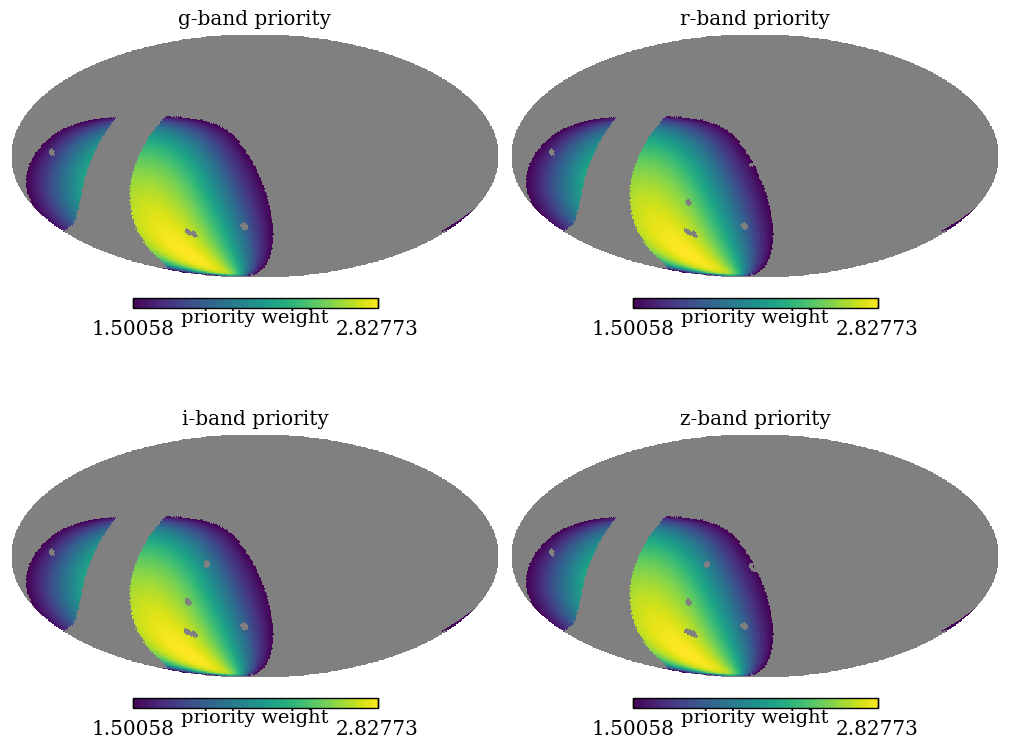

Total sky area: 41058.25 deg2


In [56]:
fig = plt.figure(figsize=(10, 8))
_sum = 0
for i, b in enumerate(BANDS):
    _map = priority_masks[b]
    msk = _map<=1.5
    _map[msk] = np.nan
    hp.mollview(
        # priority_masks[b],
        _map,
        sub=(2, 2, i + 1),
        title=f"{b}-band priority",
        unit="priority weight",
        cmap="viridis",
        fig=fig.number,
    )

    n_valid = np.sum(~np.isnan(_map))
    print(f"{b}: {n_valid} valid pixels ({n_valid/npix:.1%} of sky), \
    {b}: {n_valid*hp.nside2pixarea(64,degrees=True)} deg2 sky area, "
          f"weight range [{np.nanmin(m):.2f}, {np.nanmax(m):.2f}]")
    _sum+=n_valid*hp.nside2pixarea(64,degrees=True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "priority_masks.png"), dpi=150)
plt.show()
print(f"Total sky area: {_sum:.2f} deg2")

## Save outputs

One `float32` HEALPix map per band, nside matching `template_archive/` (RING order), `NaN` for
masked (Galactic plane / `dec > 30Β°` / already-templated) pixels.

In [11]:
for b in BANDS:
    out_path = os.path.join(OUT_DIR, f"{b}_priority_mask.npy")
    np.save(out_path, priority_masks[b])
    print(f"wrote {out_path}")

wrote priority_masks/g_priority_mask.npy
wrote priority_masks/r_priority_mask.npy
wrote priority_masks/i_priority_mask.npy
wrote priority_masks/z_priority_mask.npy


## Distribution of sky weights

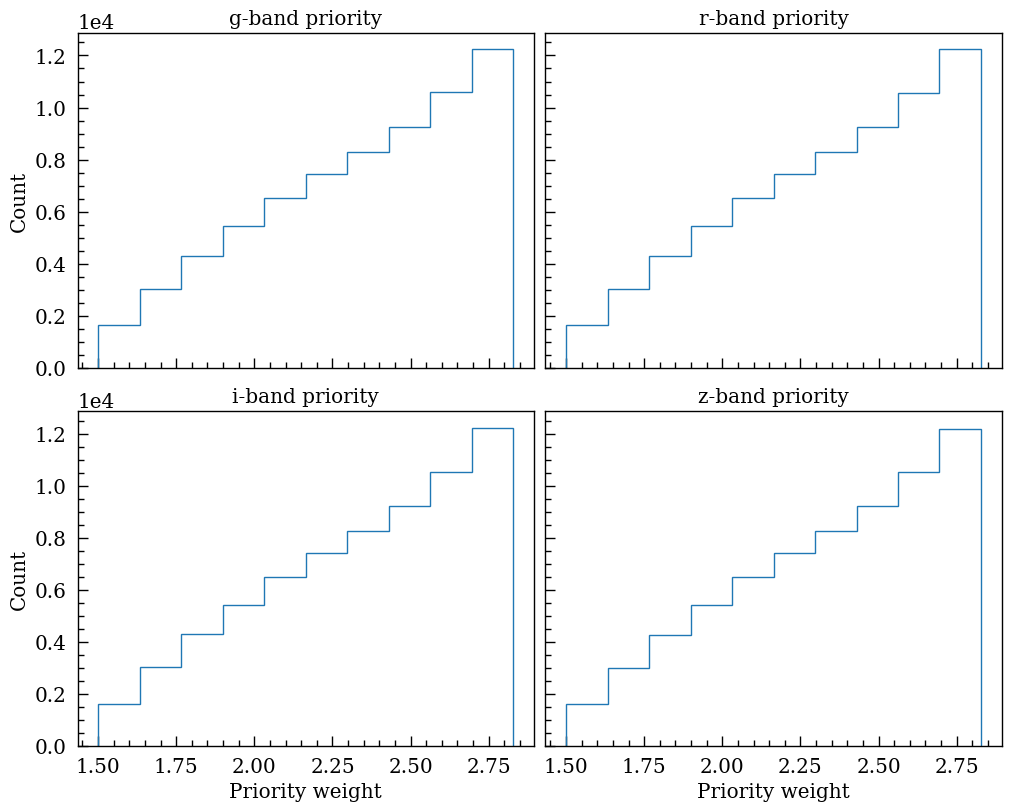

In [43]:
fig,axs = plt.subplots(2,2,figsize=(10, 8),layout='constrained',sharex=True,sharey=True)
for i, ax in enumerate(axs.flatten()):
    b = list(priority_masks.keys())[i]
    ax.hist(priority_masks[b],histtype='step',cumulative=True,
            # weights=np.full(np.shape(priority_masks[b]),hp.nside2pixarea(hp.get_nside(priority_masks[b]),degrees=True)/hp.nside2npix(hp.get_nside(priority_masks[b])))
           )
    ax.set_title(f"{b}-band priority")
for ax in axs[:,0]:
    ax.set_ylabel("Count")
for ax in axs[-1,:]:
    ax.set_xlabel("Priority weight")
plt.savefig(os.path.join(OUT_DIR, "priority_masks_dist.png"), dpi=150)
plt.show()